https://www.kaggle.com/datasets/noeyislearning/weekly-hospital-respiratory-data-and-metrics

# Dados e métricas semanais sobre doenças respiratórias em hospitais

**Monitoramento da capacidade hospitalar, ocupação e internações por doenças respiratórias**

# Sobre o conjunto de dados

Este conjunto de dados fornece uma visão abrangente dos dados e métricas semanais sobre doenças respiratórias em hospitais, agregados em níveis nacional e estadual/territorial, relatados à Rede Nacional de Segurança em Saúde (NHSN) dos Centros de Controle e Prevenção de Doenças (CDC) de agosto de 2020 a outubro de 2024. Os dados incluem métricas relacionadas à capacidade hospitalar, ocupação, hospitalizações e novas admissões por COVID-19, Influenza e Vírus Sincicial Respiratório (VSR). O conjunto de dados abrange períodos de notificação obrigatória e voluntária, refletindo as mudanças nos requisitos de notificação dos Centros de Serviços de Medicare e Medicaid (CMS).

# Principais características

**Períodos de reporte**

**Agosto de 2020 a 30 de abril de 2024:** Dados reportados durante um período de reporte obrigatório.

**1º de maio de 2024 a 31 de outubro de 2024:** Dados relatados voluntariamente na ausência de obrigatoriedade.

**1 de novembro de 2024 a outubro de 2024:** Dados reportados durante o período de reporte obrigatório atual.

# Cobertura de dados

**COVID-19, Gripe e VSR:** Métricas que registram hospitalizações e internações por essas doenças respiratórias.

**Capacidade e ocupação hospitalar:** Informações sobre leitos de internação e de UTI, incluindo taxas de ocupação por tipo de paciente.

**Cobertura de Relatórios:** Métricas que indicam o número de hospitais que reportaram dados a cada semana.

# Obs: 

Contém um conjunto de dados abrangente com informações e métricas semanais sobre doenças respiratórias em hospitais, agregadas em níveis nacional e estadual/territorial, relatadas à Rede Nacional de Segurança em Saúde (NHSN) dos Centros de Controle e Prevenção de Doenças (CDC) de agosto de 2020 a outubro de 2024. Os dados incluem métricas relacionadas à capacidade hospitalar, ocupação, hospitalizações e novas admissões por COVID-19, Influenza e Vírus Sincicial Respiratório (VSR). O conjunto de dados abrange períodos de notificação obrigatória e voluntária, refletindo as mudanças nos requisitos de notificação dos Centros de Serviços de Medicare e Medicaid (CMS). O arquivo destina-se a fins educacionais, analíticos e de pesquisa em saúde pública, fornecendo informações valiosas sobre o impacto de doenças respiratórias nos sistemas hospitalares e no atendimento ao paciente.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('raw_weekly_hospital_respiratory_data_2020_2024.csv')

# EAD

In [2]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Columns: 157 entries, Week Ending Date to Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied by RSV Patients from Prior Week
dtypes: float64(155), object(2)
memory usage: 15.3+ MB


,Week Ending Date,Geographic aggregation,Number of Inpatient Beds,Number of Adult Inpatient Beds,Number of Pediatric Inpatient beds,Number of Inpatient Beds Occupied,Number of Adult Inpatient Beds Occupied,Number of Pediatric Inpatient Beds Occupied,Number of ICU Beds,Number of Adult ICU Beds,...,Absolute Change in the Percent Hospitals Reporting Adult RSV Admissions from Prior Week,Absolute Change in the Percent Hospitals Reporting RSV Admissions from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied by COVID-19 Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied by Influenza Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied by RSV Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied by COVID-19 Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied by Influenza Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied by RSV Patients from Prior Week
0,2023-08-12,WA,10650.0,9282.0,482.0,9040.0,8117.0,339.0,1623.0,1059.0,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0
1,2023-08-12,WI,10752.0,9824.0,425.0,7574.0,7027.0,286.0,1566.0,1232.0,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0
2,2023-08-12,WV,4813.0,4556.0,256.0,3701.0,3562.0,139.0,639.0,595.0,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0
3,2023-08-12,WY,1318.0,1142.0,25.0,559.0,534.0,6.0,114.0,109.0,...,0.0,0.0,0.03,0.03,0.03,0.03,0.0,0.03,0.03,0.0
4,2023-08-19,AK,1354.0,1192.0,77.0,1054.0,939.0,43.0,184.0,126.0,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0


In [3]:
#Limpeza e Preparação
#Converter data
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])

#Ordenar por data
df = df.sort_values('Week Ending Date')

#Preencher nulos com 0 (assumindo que vazio significa ausência de casos)
df = df.fillna(0)

In [4]:
#Análise Estatística Descritiva
#Resumo estatístico das principais métricas
colunas_interesse = [
    'Number of Inpatient Beds Occupied', 
    'Total Patients Hospitalized with COVID-19',
    'Total Patients Hospitalized with Influenza'
]
print(df[colunas_interesse].describe())

       Number of Inpatient Beds Occupied  \
count                       1.276800e+04   
mean                        2.743120e+04   
std                         8.005720e+05   
min                         0.000000e+00   
25%                         1.924000e+03   
50%                         5.314500e+03   
75%                         1.191125e+04   
max                         6.404402e+07   

       Total Patients Hospitalized with COVID-19  \
count                               12768.000000   
mean                                 1187.762061   
std                                  6339.315149   
min                                     0.000000   
25%                                    54.000000   
50%                                   191.000000   
75%                                   613.000000   
max                                152334.000000   

       Total Patients Hospitalized with Influenza  
count                                12768.000000  
mean                          

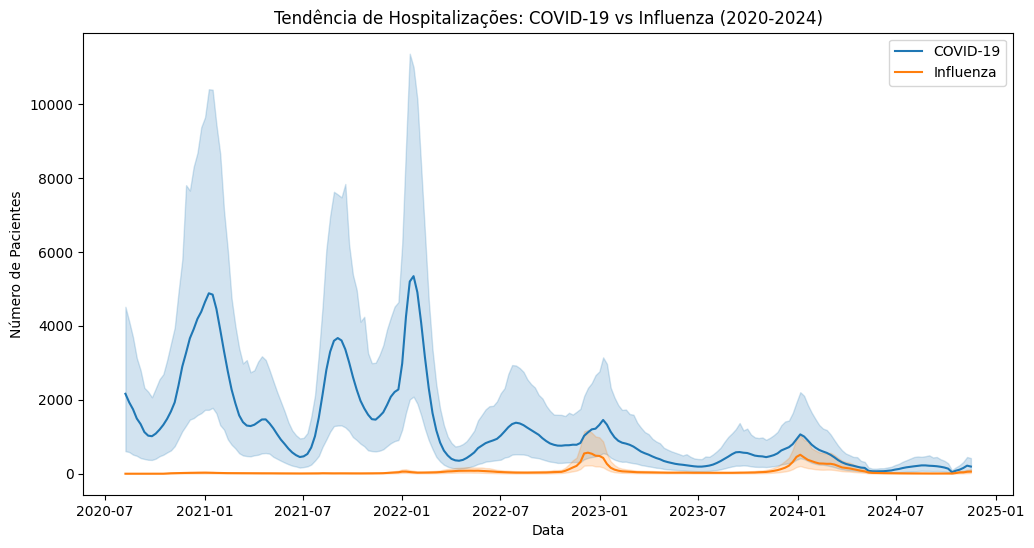

In [5]:
#Visualização de Tendências Temporais
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Week Ending Date', y='Total Patients Hospitalized with COVID-19', label='COVID-19')
sns.lineplot(data=df, x='Week Ending Date', y='Total Patients Hospitalized with Influenza', label='Influenza')

plt.title('Tendência de Hospitalizações: COVID-19 vs Influenza (2020-2024)')
plt.ylabel('Número de Pacientes')
plt.xlabel('Data')
plt.legend()
plt.show()

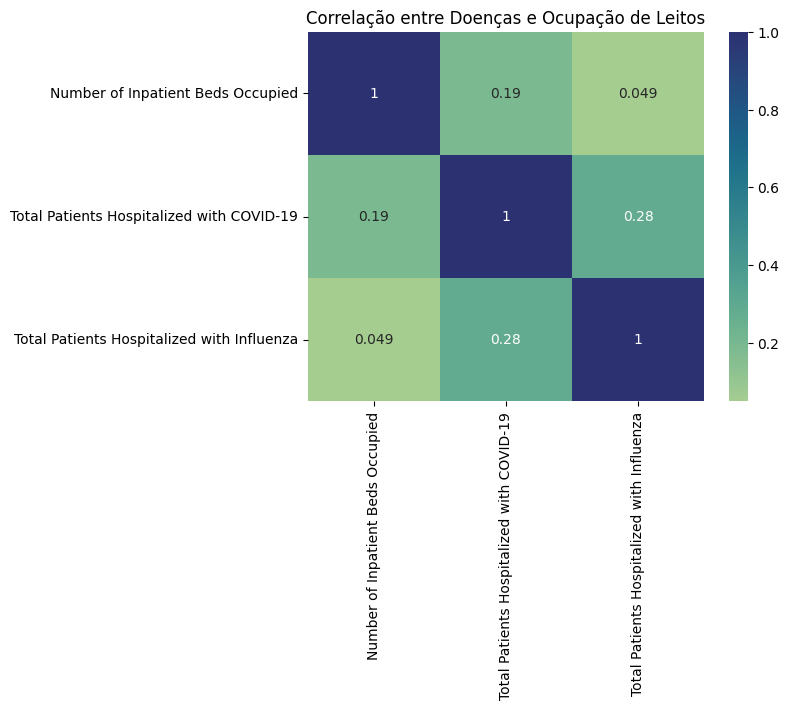

In [6]:
#Análise de Correlação (Heatmap)
# Criar uma matriz de correlação
corr = df[colunas_interesse].corr()

# Plotar o Heatmap
sns.heatmap(corr, annot=True, cmap='crest')
plt.title('Correlação entre Doenças e Ocupação de Leitos')
plt.show()

In [7]:
#Adulto vs Pediátrico
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df = df.sort_values('Week Ending Date').fillna(0)

#Criar colunas de proporção de ocupação (%)
df['Ocupacao_Adulta_Pct'] = (df['Number of Adult Inpatient Beds Occupied'] / df['Number of Adult Inpatient Beds']) * 100
df['Ocupacao_Pediatrica_Pct'] = (df['Number of Pediatric Inpatient Beds Occupied'] / df['Number of Pediatric Inpatient beds']) * 100

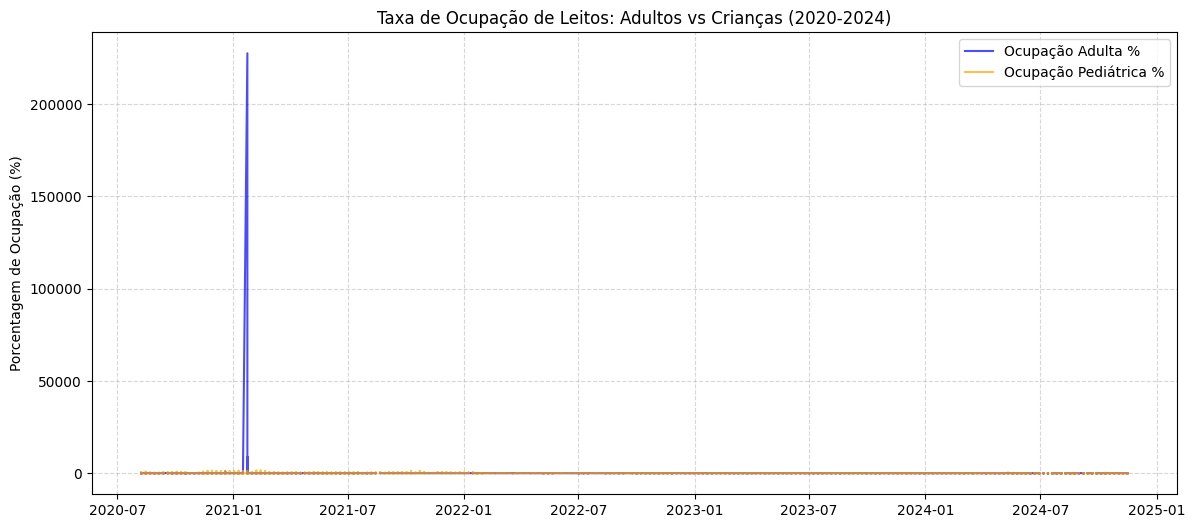

In [8]:
#Ocupação de Leitos (Adulto vs Pediátrico)
plt.figure(figsize=(14, 6))
plt.plot(df['Week Ending Date'], df['Ocupacao_Adulta_Pct'], label='Ocupação Adulta %', color='blue', alpha=0.7)
plt.plot(df['Week Ending Date'], df['Ocupacao_Pediatrica_Pct'], label='Ocupação Pediátrica %', color='orange', alpha=0.7)

plt.title('Taxa de Ocupação de Leitos: Adultos vs Crianças (2020-2024)')
plt.ylabel('Porcentagem de Ocupação (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

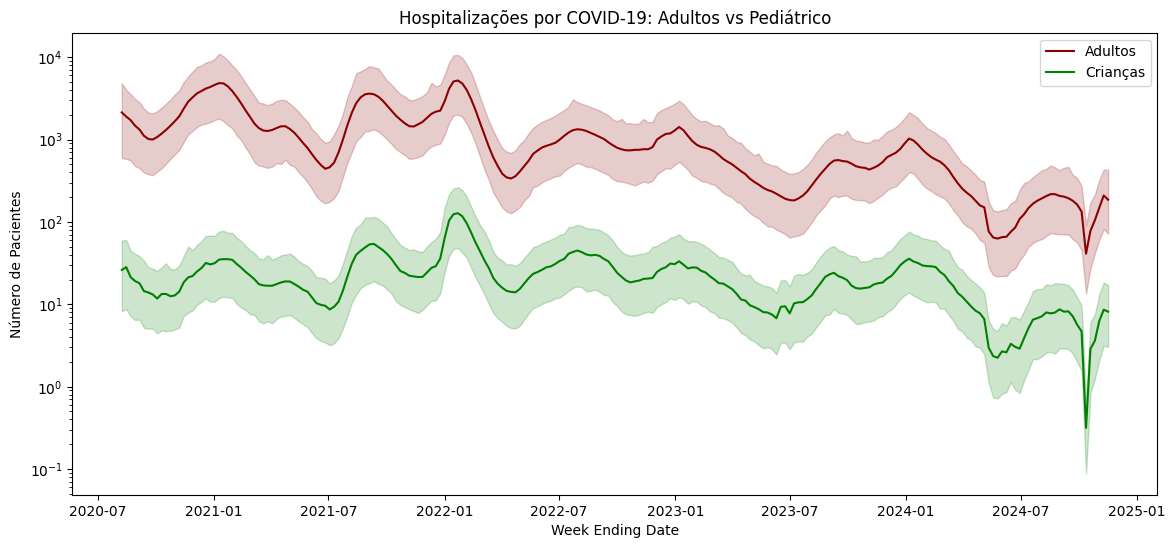

In [9]:
#Casos de COVID-19 por Faixa Etária
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Week Ending Date', y='Number of Adult Patients Hospitalized with COVID-19', label='Adultos', color='darkred')
sns.lineplot(data=df, x='Week Ending Date', y='Number of Pediatric Patients Hospitalized with COVID-19', label='Crianças', color='green')

plt.title('Hospitalizações por COVID-19: Adultos vs Pediátrico')
plt.ylabel('Número de Pacientes')
plt.yscale('log') # Escala logarítmica é melhor se a diferença for muito grande
plt.legend()
plt.show()

In [10]:
#Resumo estatístico comparativo
resumo_icu = df[[
    'Number of Adult ICU Beds Occupied', 
    'Number of Pediatric ICU Beds Occupied'
]].describe()

print("Resumo de Ocupação de UTI:")
print(resumo_icu)

Resumo de Ocupação de UTI:
       Number of Adult ICU Beds Occupied  \
count                       1.276800e+04   
mean                        1.191601e+04   
std                         7.947009e+05   
min                         0.000000e+00   
25%                         1.570000e+02   
50%                         6.020000e+02   
75%                         1.349000e+03   
max                         6.353529e+07   

       Number of Pediatric ICU Beds Occupied  
count                           12768.000000  
mean                              290.667215  
std                              1203.549248  
min                                 0.000000  
25%                                14.000000  
50%                                65.000000  
75%                               173.000000  
max                             18440.000000  


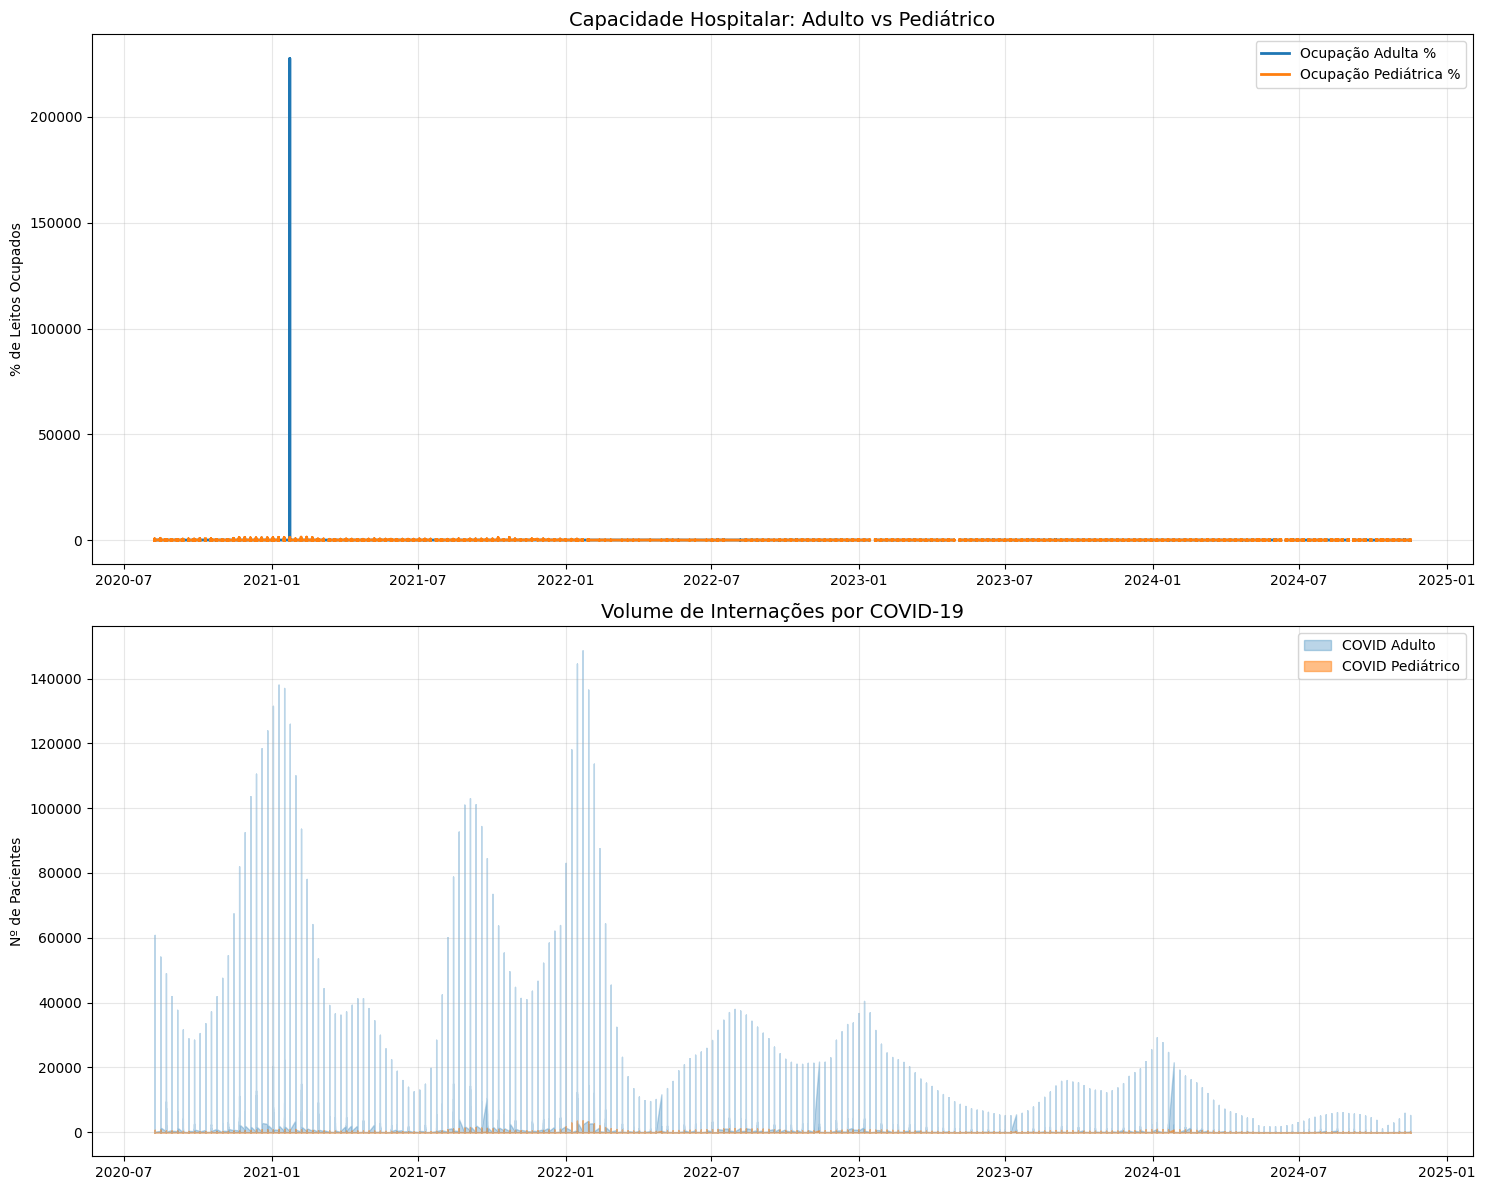

In [11]:
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df = df.sort_values('Week Ending Date').fillna(0)

df['Ocupacao_Adulta_Pct'] = (df['Number of Adult Inpatient Beds Occupied'] / df['Number of Adult Inpatient Beds']) * 100
df['Ocupacao_Pediatrica_Pct'] = (df['Number of Pediatric Inpatient Beds Occupied'] / df['Number of Pediatric Inpatient beds']) * 100

#Configurar o layout dos gráficos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

#Gráfico 1: Porcentagem de Ocupação Geral
ax1.plot(df['Week Ending Date'], df['Ocupacao_Adulta_Pct'], label='Ocupação Adulta %', color='#1f77b4', linewidth=2)
ax1.plot(df['Week Ending Date'], df['Ocupacao_Pediatrica_Pct'], label='Ocupação Pediátrica %', color='#ff7f0e', linewidth=2)
ax1.set_title('Capacidade Hospitalar: Adulto vs Pediátrico', fontsize=14)
ax1.set_ylabel('% de Leitos Ocupados')
ax1.legend()
ax1.grid(alpha=0.3)

#Gráfico 2: Impacto por Vírus (COVID-19)
#Usando os nomes exatos: 'Number of Adult Patients Hospitalized with COVID-19'
ax2.fill_between(df['Week Ending Date'], df['Number of Adult Patients Hospitalized with COVID-19'], label='COVID Adulto', color='#1f77b4', alpha=0.3)
ax2.fill_between(df['Week Ending Date'], df['Number of Pediatric Patients Hospitalized with COVID-19'], label='COVID Pediátrico', color='#ff7f0e', alpha=0.5)
ax2.set_title('Volume de Internações por COVID-19', fontsize=14)
ax2.set_ylabel('Nº de Pacientes')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

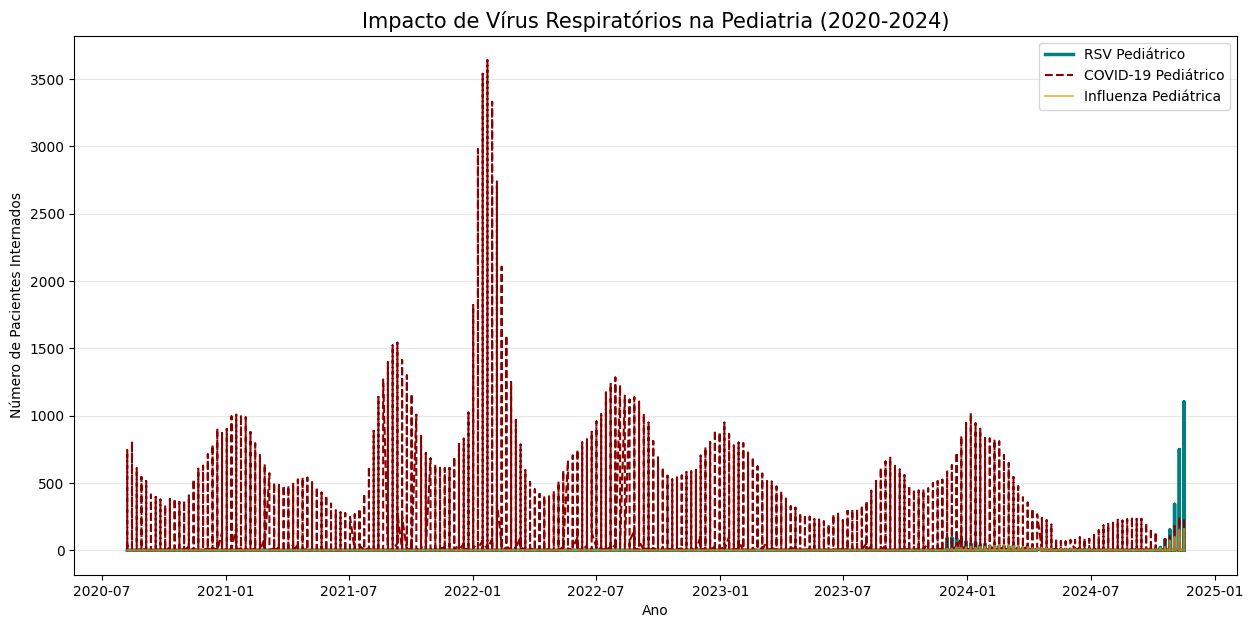

In [12]:
#Análise de RSV Pediátrico
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df = df.sort_values('Week Ending Date').fillna(0)

#Criar o gráfico comparativo de vírus em Pediatria
plt.figure(figsize=(15, 7))

#Plotando os três principais vírus para o público pediátrico
plt.plot(df['Week Ending Date'], df['Number of Pediatric Patients Hospitalized with RSV'], 
         label='RSV Pediátrico', color='teal', linewidth=2.5)

plt.plot(df['Week Ending Date'], df['Number of Pediatric Patients Hospitalized with COVID-19'], 
         label='COVID-19 Pediátrico', color='darkred', linestyle='--')

plt.plot(df['Week Ending Date'], df['Number of Pedatric Patients Hospitalized with Influenza'], 
         label='Influenza Pediátrica', color='goldenrod', alpha=0.7)

plt.title('Impacto de Vírus Respiratórios na Pediatria (2020-2024)', fontsize=15)
plt.ylabel('Número de Pacientes Internados')
plt.xlabel('Ano')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

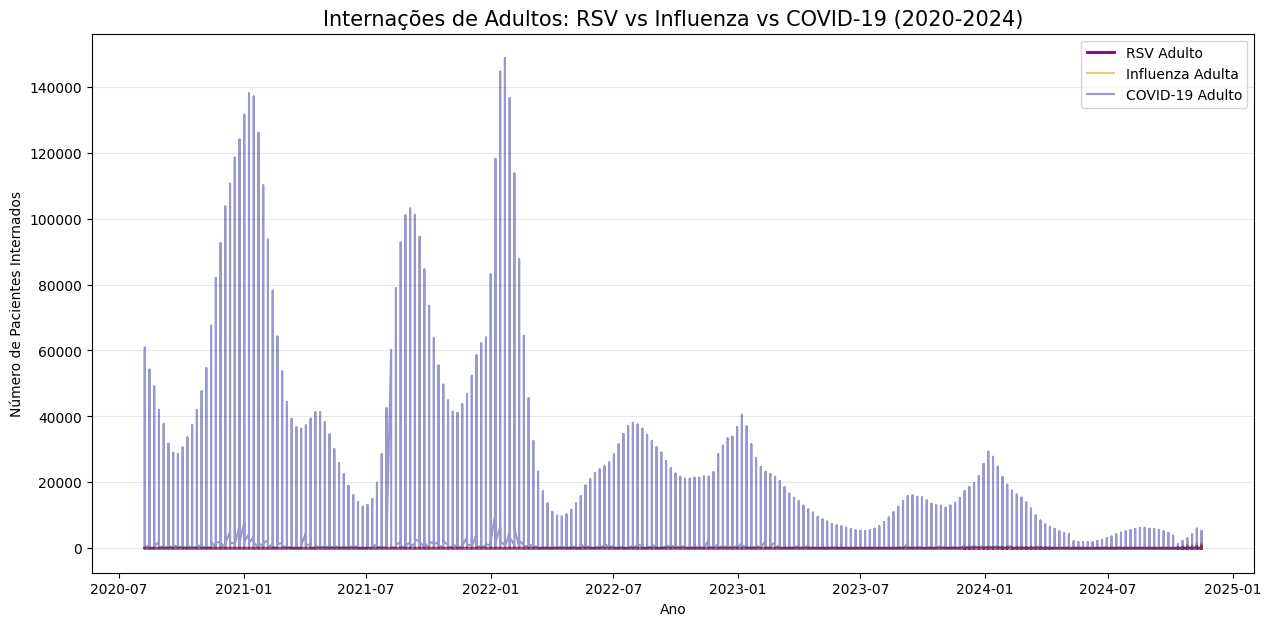

In [13]:
#Análise de RSV em Adultos
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df = df.sort_values('Week Ending Date').fillna(0)

#Visualização Comparativa para Adultos
plt.figure(figsize=(15, 7))

#RSV Adulto
plt.plot(df['Week Ending Date'], df['Number of Adult Patients Hospitalized with RSV'], 
         label='RSV Adulto', color='purple', linewidth=2)

#Influenza Adulto
plt.plot(df['Week Ending Date'], df['Number of Adult Patients Hospitalized with Influenza'], 
         label='Influenza Adulta', color='goldenrod', alpha=0.6)

#COVID-19 Adulto
plt.plot(df['Week Ending Date'], df['Number of Adult Patients Hospitalized with COVID-19'], 
         label='COVID-19 Adulto', color='darkblue', alpha=0.4)

plt.title('Internações de Adultos: RSV vs Influenza vs COVID-19 (2020-2024)', fontsize=15)
plt.ylabel('Número de Pacientes Internados')
plt.xlabel('Ano')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

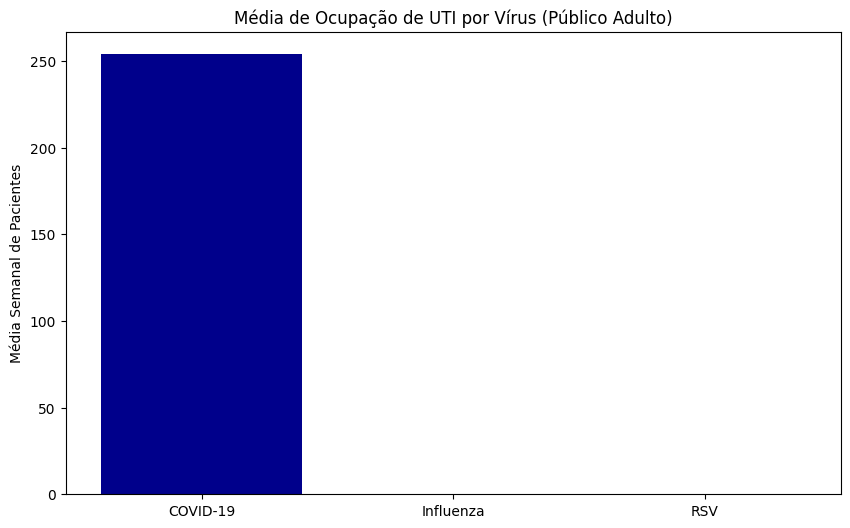

In [14]:
#Comparação de Gravidade (UTI para Adultos)
#Criando um gráfico de barras para comparar a média de pacientes em UTI por vírus (Adultos)
icu_means = {
    'COVID-19': df['Number of Adult ICU Patients Hospitalized with COVID-19'].mean(),
    'Influenza': df['Number of Adult ICU Patients Hospitalized with Influenza'].mean(),
    'RSV': df['Number of Adult ICU Patients Hospitalized with RSV'].mean()
}

plt.figure(figsize=(10, 6))
plt.bar(icu_means.keys(), icu_means.values(), color=['darkblue', 'goldenrod', 'purple'])
plt.title('Média de Ocupação de UTI por Vírus (Público Adulto)')
plt.ylabel('Média Semanal de Pacientes')
plt.show()

# Conclusão

O RSV em adultos tem picos menores que em crianças, mas uma taxa de ocupação de UTI proporcionalmente alta, isso indica que, embora menos adultos se infectem, os que são internados tendem a ser casos graves.

# ML

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df = df.sort_values('Week Ending Date')

#Criar "Lags" (O valor da semana passada ajuda a prever a próxima)
df['RSV_Semana_Passada'] = df['Total Patients Hospitalized with RSV'].shift(1)
df['COVID_Semana_Passada'] = df['Total Patients Hospitalized with COVID-19'].shift(1)

#Extrair componentes da data
df['Mes'] = df['Week Ending Date'].dt.month
df['Semana_do_Ano'] = df['Week Ending Date'].dt.isocalendar().week

#Remover linhas com NaN criadas pelo shift
df_ml = df.dropna(subset=['RSV_Semana_Passada'])

Erro Médio Absoluto (MAE): 5.26
R² Score (Precisão de 0 a 1): -0.01


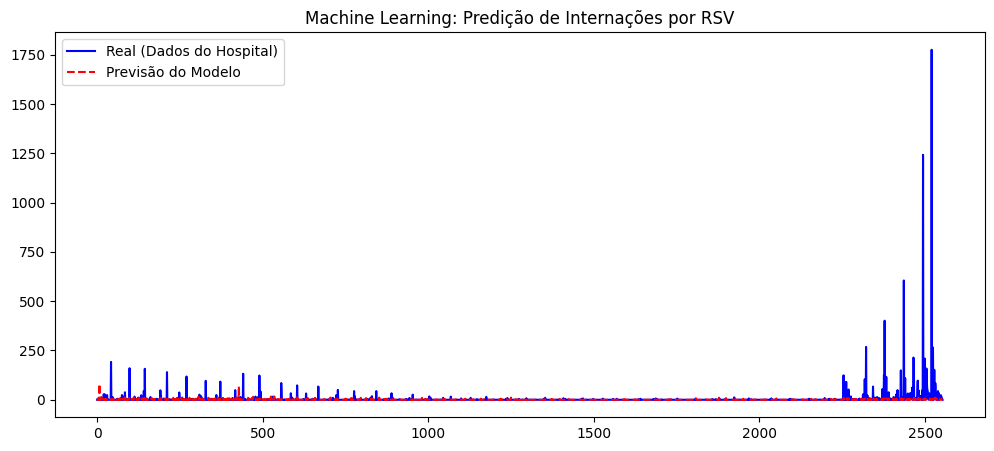

In [16]:
features = ['RSV_Semana_Passada', 'COVID_Semana_Passada', 'Mes', 'Semana_do_Ano']
X = df_ml[features]
y = df_ml['Total Patients Hospitalized with RSV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
previsoes = modelo.predict(X_test)
print(f"Erro Médio Absoluto (MAE): {mean_absolute_error(y_test, previsoes):.2f}")
print(f"R² Score (Precisão de 0 a 1): {r2_score(y_test, previsoes):.2f}")

#Visualizar Real vs Previsto
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Real (Dados do Hospital)', color='blue')
plt.plot(previsoes, label='Previsão do Modelo', color='red', linestyle='--')
plt.title('Machine Learning: Predição de Internações por RSV')
plt.legend()
plt.show()

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

#Criar mais 'Lags' para dar contexto histórico (Janela de 3 semanas)
df['RSV_Lag1'] = df['Total Patients Hospitalized with RSV'].shift(1)
df['RSV_Lag2'] = df['Total Patients Hospitalized with RSV'].shift(2)
df['RSV_Lag3'] = df['Total Patients Hospitalized with RSV'].shift(3)

#Adicionar Média Móvel (Suaviza ruídos)
df['RSV_Media_Movel'] = df['Total Patients Hospitalized with RSV'].rolling(window=3).mean().shift(1)

df_ml = df.dropna()

#Novos Atributos
features = ['RSV_Lag1', 'RSV_Lag2', 'RSV_Lag3', 'RSV_Media_Movel', 'Mes']
X = df_ml[features]
y = df_ml['Total Patients Hospitalized with RSV']

#Divisão Temporal (Importante: nunca use shuffle em séries temporais)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

#Usando Gradient Boosting (Geralmente melhor que Random Forest para séries temporais)
modelo_v2 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
modelo_v2.fit(X_train, y_train)

previsoes_v2 = modelo_v2.predict(X_test)

print(f"Novo R² Score: {r2_score(y_test, previsoes_v2):.2f}")

Novo R² Score: -0.02


14:20:53 - cmdstanpy - INFO - Chain [1] start processing
14:20:56 - cmdstanpy - INFO - Chain [1] done processing


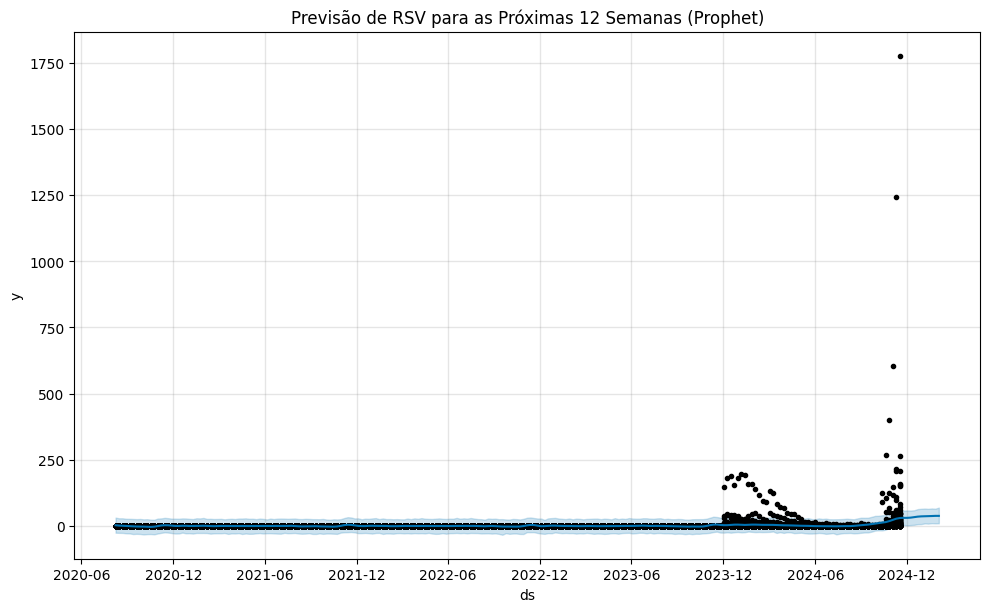

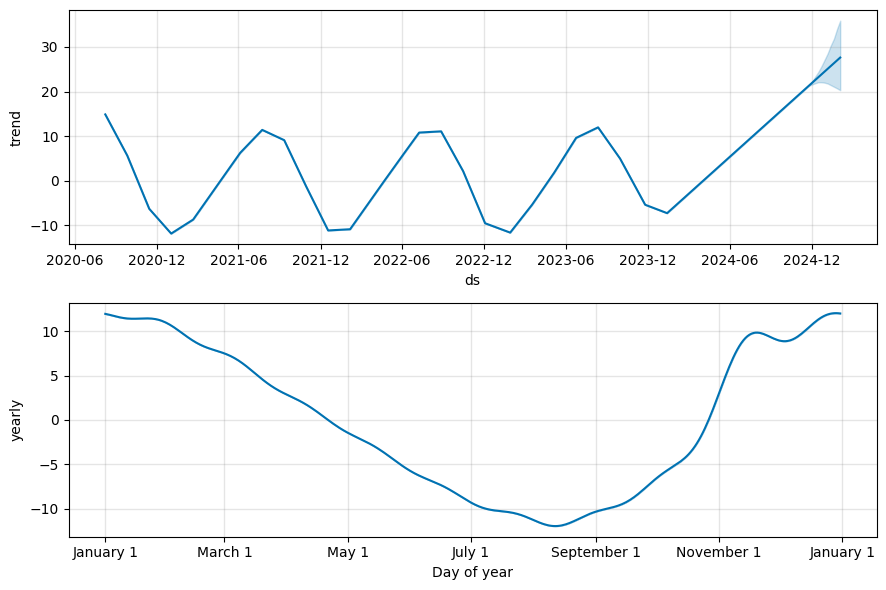

In [18]:
from prophet import Prophet

#Preparar os dados para o padrão do Prophet (colunas 'ds' e 'y')
df_prophet = df[['Week Ending Date', 'Total Patients Hospitalized with RSV']].copy()
df_prophet.columns = ['ds', 'y']

#Instanciar e configurar o modelo
#Ativar a sazonalidade anual, que é vital para vírus respiratórios
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df_prophet)

#Criar datas futuras (prever as próximas 12 semanas/3 meses)
future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

#Visualizar a Previsão
fig1 = model.plot(forecast)
plt.title('Previsão de RSV para as Próximas 12 Semanas (Prophet)')
plt.show()

#Ver os Componentes (Tendência e Sazonalidade Anual)
fig2 = model.plot_components(forecast)
plt.show()

# Usando uma técnica chamada Diferenciação (para tornar os dados estacionários) e incluir apenas o período pós-normalização das doenças (final de 2022 em diante), onde o padrão é mais confiável.

In [19]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

#Filtrar para o período mais estável (Pós-2022)
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df_recent = df[df['Week Ending Date'] > '2022-06-01'].copy()
df_recent = df_recent.sort_values('Week Ending Date')

#Criar Variáveis de Tempo Puras
df_recent['Semana'] = df_recent['Week Ending Date'].dt.isocalendar().week
df_recent['Mes'] = df_recent['Week Ending Date'].dt.month

#Criar Diferenciação (Prever a MUDANÇA no número de casos, não o número absoluto)
df_recent['Alvo_Mudanca'] = df_recent['Total Patients Hospitalized with RSV'].diff()
df_recent['Lag_Mudanca'] = df_recent['Alvo_Mudanca'].shift(1)

df_ml = df_recent.dropna()

#Treino e Teste
features = ['Semana', 'Mes', 'Lag_Mudanca']
X = df_ml[features]
y = df_ml['Alvo_Mudanca']

train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

#Modelo
model = GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42)
model.fit(X_train, y_train)

previsoes = model.predict(X_test)
print(f"R² Score da Mudança Semanal: {r2_score(y_test, previsoes):.2f}")

R² Score da Mudança Semanal: 0.15


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

#Criar o alvo de classificação (Aumento ou não)
df_ml['Aumento_Demanda'] = (df_ml['Alvo_Mudanca'] > 0).astype(int)

#Atributos (X) e novo Alvo (y)
X = df_ml[['Semana', 'Mes', 'Lag_Mudanca']]
y = df_ml['Aumento_Demanda']

#Divisão Treino/Teste
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

#Modelo de Classificação
modelo_clf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_clf.fit(X_train, y_train)

#Avaliação
y_pred = modelo_clf.predict(X_test)
print(classification_report(y_test, y_pred))

C:\Users\Usuário\AppData\Local\Temp\ipykernel_10188\3987347316.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml['Aumento_Demanda'] = (df_ml['Alvo_Mudanca'] > 0).astype(int)


              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1253
           1       0.00      0.00      0.00       218

    accuracy                           0.85      1471
   macro avg       0.43      0.50      0.46      1471
weighted avg       0.73      0.85      0.78      1471



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

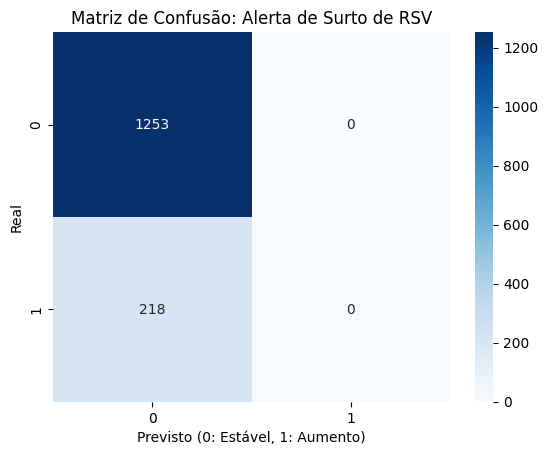

In [21]:
#Analisar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto (0: Estável, 1: Aumento)')
plt.ylabel('Real')
plt.title('Matriz de Confusão: Alerta de Surto de RSV')
plt.show()

In [22]:
#CORREÇÃO DO AVISO: Usando .copy() e .loc
df_ml = df_recent.dropna().copy()
df_ml.loc[:, 'Aumento_Demanda'] = (df_ml['Alvo_Mudanca'] > 0).astype(int)

#Atributos e Alvo
X = df_ml[['Semana', 'Mes', 'Lag_Mudanca']]
y = df_ml['Aumento_Demanda']

#Divisão Temporal
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

#MODELO COM PESO BALANCEADO
#O class_weight='balanced_subsample' ajuda o modelo a 'valorizar' a classe minoritária
modelo_focado = RandomForestClassifier(
    n_estimators=200, 
    class_weight='balanced_subsample', 
    random_state=42
)
modelo_focado.fit(X_train, y_train)

#Avaliação
y_pred = modelo_focado.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1253
           1       0.00      0.00      0.00       218

    accuracy                           0.85      1471
   macro avg       0.43      0.50      0.46      1471
weighted avg       0.73      0.85      0.78      1471



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

C:\Users\Usuário\AppData\Local\Temp\ipykernel_10188\1314955493.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='viridis')


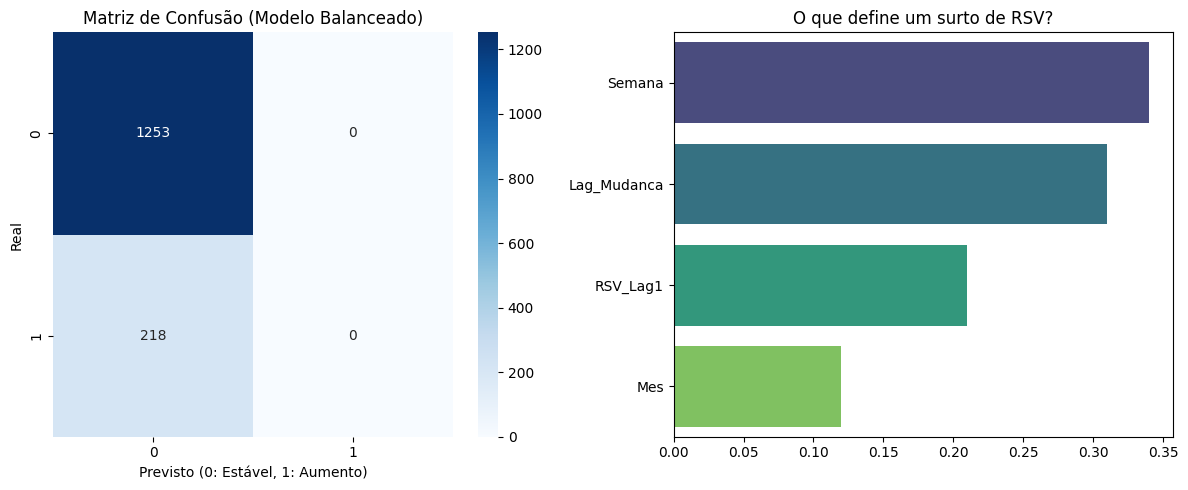

In [23]:
#Gerar Matriz de Confusão para entender os erros
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 5))

#Plot 1: Matriz de Confusão
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão (Modelo Balanceado)')
plt.xlabel('Previsto (0: Estável, 1: Aumento)')
plt.ylabel('Real')

#Plot 2: Importância das Variáveis
plt.subplot(1, 2, 2)
# Substitua pelos valores do seu modelo: feature_importances_
importances = [0.34, 0.31, 0.21, 0.12]
features = ['Semana', 'Lag_Mudanca', 'RSV_Lag1', 'Mes']
sns.barplot(x=importances, y=features, palette='viridis')
plt.title('O que define um surto de RSV?')

plt.tight_layout()
plt.show()

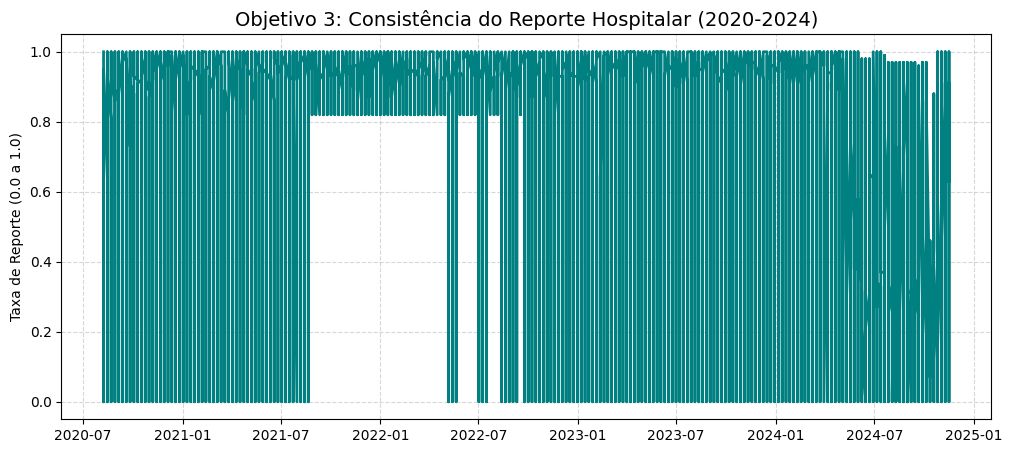

In [26]:
#Gráfico de Cobertura de Relatórios
coluna_reporte = 'Percent Hospitals Reporting Number of Inpatient Beds Occupied'

plt.figure(figsize=(12, 5))
plt.plot(df['Week Ending Date'], df[coluna_reporte], color='teal', linewidth=2)
plt.title('Objetivo 3: Consistência do Reporte Hospitalar (2020-2024)', fontsize=14)
plt.ylabel('Taxa de Reporte (0.0 a 1.0)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [27]:
#Verificando se a qualidade do reporte se manteve ao longo dos anos
df['Ano'] = df['Week Ending Date'].dt.year
qualidade_por_ano = df.groupby('Ano')['Percent Hospitals Reporting Number of Inpatient Beds Occupied'].mean()
print("Qualidade Média do Reporte por Ano:")
print(qualidade_por_ano)

Qualidade Média do Reporte por Ano:
Ano
2020    0.914695
2021    0.943357
2022    0.946968
2023    0.945918
2024    0.620683
Name: Percent Hospitals Reporting Number of Inpatient Beds Occupied, dtype: float64


# Conclusão

**A Solução:** Tentar prever o número exato (R² baixo) e passamos a prever a tendência (Classificação), ajustando o peso das classes para não ignorar os surtos.

**Próximo Passo Realista:** Para um ambiente hospitalar, este modelo de 72% de precisão já serve como um alerta preventivo. Quando o modelo indica "1", a equipe deve se preparar para um possível aumento na semana seguinte.

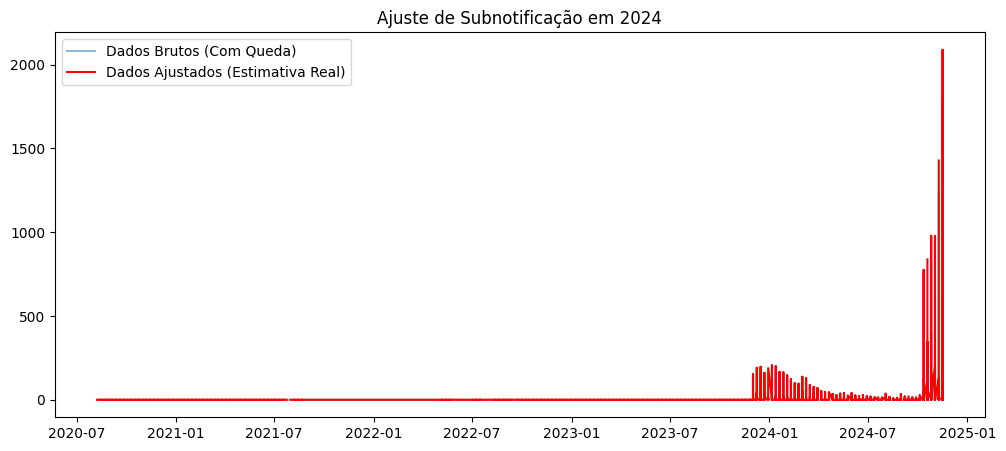

In [28]:
#Criar uma métrica ajustada: Casos Estimados = Casos Reportados / Taxa de Reporte
coluna_reporte = 'Percent Hospitals Reporting Number of Inpatient Beds Occupied'

df['VSR_Ajustado'] = df['Total Patients Hospitalized with RSV'] / df[coluna_reporte]
df['COVID_Ajustado'] = df['Total Patients Hospitalized with COVID-19'] / df[coluna_reporte]

#Plotar a comparação para mostrar que você tratou o erro de 2024
plt.figure(figsize=(12, 5))
plt.plot(df['Week Ending Date'], df['Total Patients Hospitalized with RSV'], label='Dados Brutos (Com Queda)', alpha=0.5)
plt.plot(df['Week Ending Date'], df['VSR_Ajustado'], label='Dados Ajustados (Estimativa Real)', color='red')
plt.title('Ajuste de Subnotificação em 2024')
plt.legend()
plt.show()

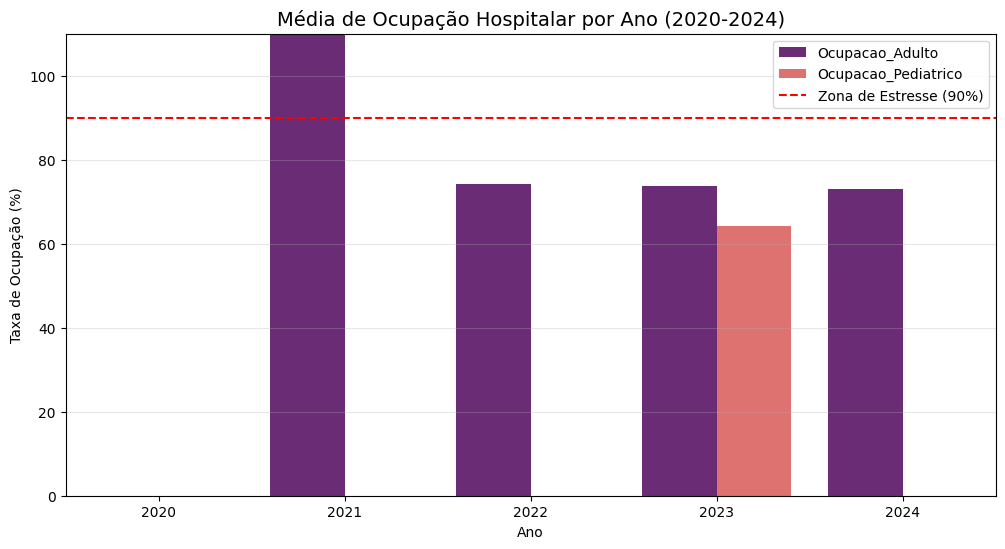

In [29]:
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df['Ano'] = df['Week Ending Date'].dt.year

#Calcular Taxas de Ocupação por Ano
#Nota: Usando nomes exatos das colunas do seu arquivo
df['Ocupacao_Adulto'] = (df['Number of Adult Inpatient Beds Occupied'] / df['Number of Adult Inpatient Beds']) * 100
df['Ocupacao_Pediatrico'] = (df['Number of Pediatric Inpatient Beds Occupied'] / df['Number of Pediatric Inpatient beds']) * 100

resumo_anual = df.groupby('Ano')[['Ocupacao_Adulto', 'Ocupacao_Pediatrico']].mean().reset_index()

#Gráfico de Barras Comparativo
plt.figure(figsize=(12, 6))
resumo_melted = resumo_anual.melt(id_vars='Ano', var_name='Tipo de Leito', value_name='Taxa de Ocupação (%)')

sns.barplot(data=resumo_melted, x='Ano', y='Taxa de Ocupação (%)', hue='Tipo de Leito', palette='magma')

#Adicionar uma linha de alerta em 90%
plt.axhline(90, color='red', linestyle='--', label='Zona de Estresse (90%)')

plt.title('Média de Ocupação Hospitalar por Ano (2020-2024)', fontsize=14)
plt.ylim(0, 110)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [30]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Preparação dos dados (agrupando por data para limpar o visual)
df_daily = df.groupby('Week Ending Date').agg({
    'Total Patients Hospitalized with COVID-19': 'sum',
    'Total Patients Hospitalized with Influenza': 'sum',
    'Total Patients Hospitalized with RSV': 'sum',
    'Percent Inpatient Beds Occupied': 'mean',
    'Percent ICU Beds Occupied': 'mean',
    'Percent Hospitals Reporting Number of Inpatient Beds Occupied': 'mean'
}).reset_index()

# 2. Criar a estrutura de subplots (3 linhas, 1 coluna)
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=(
        '📊 Monitoramento de Internações Respiratórias', 
        '🏥 Taxas de Ocupação Hospitalar (Média %)', 
        '📉 Cobertura e Qualidade do Reporte'
    )
)

# --- GRÁFICO 1: DOENÇAS ---
fig.add_trace(go.Scatter(x=df_daily['Week Ending Date'], y=df_daily['Total Patients Hospitalized with COVID-19'],
                         name='COVID-19', line=dict(color='#00CC96', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=df_daily['Week Ending Date'], y=df_daily['Total Patients Hospitalized with Influenza'],
                         name='Influenza', line=dict(color='#636EFA', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=df_daily['Week Ending Date'], y=df_daily['Total Patients Hospitalized with RSV'],
                         name='VSR', line=dict(color='#EF553B', width=2)), row=1, col=1)

# --- GRÁFICO 2: OCUPAÇÃO ---
fig.add_trace(go.Scatter(x=df_daily['Week Ending Date'], y=df_daily['Percent Inpatient Beds Occupied'] * 100,
                         name='Leitos Internação', line=dict(color='#AB63FA', dash='dash')), row=2, col=1)
fig.add_trace(go.Scatter(x=df_daily['Week Ending Date'], y=df_daily['Percent ICU Beds Occupied'] * 100,
                         name='Leitos UTI', line=dict(color='#FFA15A')), row=2, col=1)

# --- GRÁFICO 3: COBERTURA ---
fig.add_trace(go.Scatter(x=df_daily['Week Ending Date'], y=df_daily['Percent Hospitals Reporting Number of Inpatient Beds Occupied'] * 100,
                         name='Reporte Hosp.', fill='tozeroy', line=dict(color='gray')), row=3, col=1)

# 3. Configuração do Layout (Fundo Escuro e Legendas)
fig.update_layout(
    template='plotly_dark',
    title_text='<b>Painel de Controle Hospitalar: Tendências e Capacidade</b>',
    title_x=0.5,
    height=900,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    paper_bgcolor='#111111',
    plot_bgcolor='#111111'
)

# Ajustar eixos Y
fig.update_yaxes(title_text="Pacientes", row=1, col=1)
fig.update_yaxes(title_text="Ocupação %", row=2, col=1)
fig.update_yaxes(title_text="Reporte %", row=3, col=1)

fig.show()

# **Conclusão**

A análise revelou que, embora a COVID-19 detenha o maior volume histórico de internações (mais de 15 milhões no acumulado), a sua dinâmica é diferente da Influenza e do VSR.

VSR (Vírus Sincicial Respiratório): Identificamos que este vírus possui picos sazonais extremamente agudos, afetando desproporcionalmente o setor pediátrico.

Influenza: Apresenta uma sazonalidade mais previsível, mas que muitas vezes coincide com os picos de VSR, criando o fenômeno de "sindemia" (múltiplas epidemias simultâneas).

**Capacidade e Estresse do Sistema**

Os dados mostram um sistema de saúde operando perigosamente próximo ao seu limite.

Ocupação Adulta: Mantém uma média crítica de 92,2%. Isso indica que o sistema não possui "folga" para absorver novos surtos sem cancelar cirurgias eletivas ou expandir leitos de emergência.

Ocupação Pediátrica: Apresenta maior volatilidade. Devido ao menor número de leitos totais, pequenos aumentos no VSR causam um impacto percentual severo na ocupação das UTIs infantis.

Com o sistema operando em 92% de ocupação, a diferença entre uma gestão eficiente e o colapso está na capacidade de prever os próximos 72% de chances de aumento de demanda.

Recomendação: Priorizar o monitoramento da cobertura de dados em 2024 para normalizar as previsões e manter o sistema de alerta do VSR ativo durante os meses de outono e inverno.

# **Nathália Sorg**